# AI Based Spam and Phishing Detection in Emails
## Hybrid Model: XGBoost/LightGBM + LSTM

**Project Goal**: Build an advanced message security system using multiple state-of-the-art algorithms for SMS and Email messages
---
### What You'll Learn:
✅ Traditional ML: XGBoost, LightGBM (Industry Standard)  
✅ Deep Learning: LSTM Neural Networks  
✅ Feature Engineering: TF-IDF + Advanced Techniques  
✅ Model Comparison: Visualizations & Metrics  
✅ Production Deployment: Save & Load Models  

## SECTION 1 INSTALL ADVANCED LIBRARIES

We're using industry-standard libraries:
- **XGBoost** & **LightGBM**: Gradient Boosting (Used by Google, Microsoft, Amazon)
- **TensorFlow/Keras**: Deep Learning Framework
- **scikit-learn**: Traditional ML algorithms
- **NLTK**: Natural Language Processing

In [1]:
# Install required packages
%pip install -q tensorflow keras xgboost lightgbm scikit-learn nltk matplotlib seaborn pandas numpy

# Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout, LSTM, Embedding, SpatialDropout1D
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries loaded successfully!")
print(f"TensorFlow Version: {tf.__version__}")
print(f"XGBoost Version: {xgb.__version__}")
print(f"LightGBM Version: {lgb.__version__}")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ All libraries loaded successfully!
TensorFlow Version: 2.21.0
XGBoost Version: 3.1.3
LightGBM Version: 4.6.0


## SECTION 2: DATA LOADING & PREPARATION

In [2]:
import os
import glob
import pandas as pd

os.chdir(r'c:\Users\Piyush\Desktop\AI and ML Projects\Email spam Classification')

# ✅ Load CLEANED unified dataset with validated Category and Message columns
# This dataset has been thoroughly cleaned with:
# - All whitespace stripped from categories
# - Duplicates removed
# - Invalid/null values eliminated
# - All records verified and ready for ML

df = pd.read_csv('email_unified.csv', sep=',', encoding='utf-8')

# Optional: merge additional ham/spam datasets if provided
additional_sources = []
search_dirs = ['additional_data', 'extra_data', 'more_data']
for data_dir in search_dirs:
    if os.path.isdir(data_dir):
        additional_sources.extend(sorted(glob.glob(os.path.join(data_dir, '*.csv'))))

# Also check for a single extra CSV in the root folder
for candidate in ['extra_ham_spam.csv', 'additional_ham_spam.csv', 'more_ham_spam.csv', 'spam_Emails_data.csv', 'email_augmented.csv']:
    if os.path.exists(candidate):
        additional_sources.append(candidate)

additional_sources = sorted(set(additional_sources))

if additional_sources:
    print(f"\nFound {len(additional_sources)} additional dataset file(s). Merging with base dataset...")
    original_len = len(df)
    for extra_path in additional_sources:
        print(f"  • Loading: {extra_path}")
        extra_df = pd.read_csv(extra_path, sep=',', encoding='utf-8', on_bad_lines='skip')

        # Normalize column names
        extra_df.columns = [col.strip() for col in extra_df.columns]
        if 'Category' not in extra_df.columns or 'Message' not in extra_df.columns:
            if 'label' in extra_df.columns and 'text' in extra_df.columns:
                extra_df = extra_df.rename(columns={'label': 'Category', 'text': 'Message'})
            elif 'category' in extra_df.columns and 'message' in extra_df.columns:
                extra_df = extra_df.rename(columns={'category': 'Category', 'message': 'Message'})

        if 'Category' not in extra_df.columns or 'Message' not in extra_df.columns:
            print(f"    ⚠️ Skipping {extra_path}: missing Category/Message columns")
            continue

        extra_df = extra_df[['Category', 'Message']].copy()
        extra_df['Category'] = extra_df['Category'].astype(str).str.strip().str.lower()
        extra_df['Message'] = extra_df['Message'].astype(str).str.strip()
        extra_df = extra_df[extra_df['Category'].isin(['ham', 'spam', 'phishing'])]

        df = pd.concat([df, extra_df], ignore_index=True)

    df.drop_duplicates(subset=['Category', 'Message'], inplace=True)
    print(f"  ✅ Merged {len(df) - original_len:,} new rows from additional sources")
else:
    print("\nNo extra dataset files found to merge. Using only email_unified.csv.")

print("="*80)
print("DATASET OVERVIEW - CLEANED & UNIFIED DATA")
print("="*80)
print(f"\nDataset Source: email_unified.csv (from new email.csv)")
print(f"Total messages: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nDataset shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)
print(f"\n Data Quality Status:")
print(f"   • No null values in Category: {df['Category'].isnull().sum() == 0}")
print(f"   • No null values in Message: {df['Message'].isnull().sum() == 0}")
print(f"   • All categories valid: {df['Category'].isin(['ham', 'spam', 'phishing']).all()}")

# Save merged dataset so future runs start from an updated file without re-merging manually
merged_path = 'email_unified_merged.csv'
df.to_csv(merged_path, index=False)
print(f"\n✅ Merged dataset saved to: {merged_path}")


Found 2 additional dataset file(s). Merging with base dataset...
  • Loading: email_augmented.csv
  • Loading: spam_Emails_data.csv
  ✅ Merged 192,618 new rows from additional sources
DATASET OVERVIEW - CLEANED & UNIFIED DATA

Dataset Source: email_unified.csv (from new email.csv)
Total messages: 280,163
Columns: ['Category', 'Message']

First 3 rows:
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...

Dataset shape: (280163, 2)

Data types:
Category    object
Message     object
dtype: object

 Data Quality Status:
   • No null values in Category: True
   • No null values in Message: True
   • All categories valid: True

✅ Merged dataset saved to: email_unified_merged.csv


In [3]:
# Data Cleaning & Preprocessing
print("\n" + "="*80)
print("DATA CLEANING & PREPROCESSING")
print("="*80)

# Rename columns for consistency with rest of notebook
# Note: Data is already cleaned (no duplicates, no nulls, no invalid categories)
df.rename(columns={'Category': 'Target', 'Message': 'Text'}, inplace=True)

print(f"\n✅ Pre-cleaned data loaded - already optimized:")
print(f"   • No invalid categories to remove")
print(f"   • No duplicates to remove")
print(f"   • No null values to handle")
print(f"   • All {len(df):,} records are valid and ready")

# Encode target variable (already in correct format but encoding for models)
encoder = LabelEncoder()
df['Target_Encoded'] = encoder.fit_transform(df['Target'])

print(f"\nTarget Encoding:")
for i, label in enumerate(encoder.classes_):
    print(f"  {i} = {label}")

print(f"\n✅ Final dataset shape: {df.shape}")
print(f"✅ Total emails for training: {len(df):,}")
print(f"\nClass distribution:")
class_dist = df['Target'].value_counts()
for label, count in class_dist.items():
    pct = count / len(df) * 100
    print(f"  {label.upper():10s}: {count:6,} ({pct:5.2f}%)")


DATA CLEANING & PREPROCESSING

✅ Pre-cleaned data loaded - already optimized:
   • No invalid categories to remove
   • No duplicates to remove
   • No null values to handle
   • All 280,163 records are valid and ready

Target Encoding:
  0 = ham
  1 = phishing
  2 = spam

✅ Final dataset shape: (280163, 3)
✅ Total emails for training: 280,163

Class distribution:
  HAM       : 106,616 (38.05%)
  SPAM      : 91,134 (32.53%)
  PHISHING  : 82,413 (29.42%)


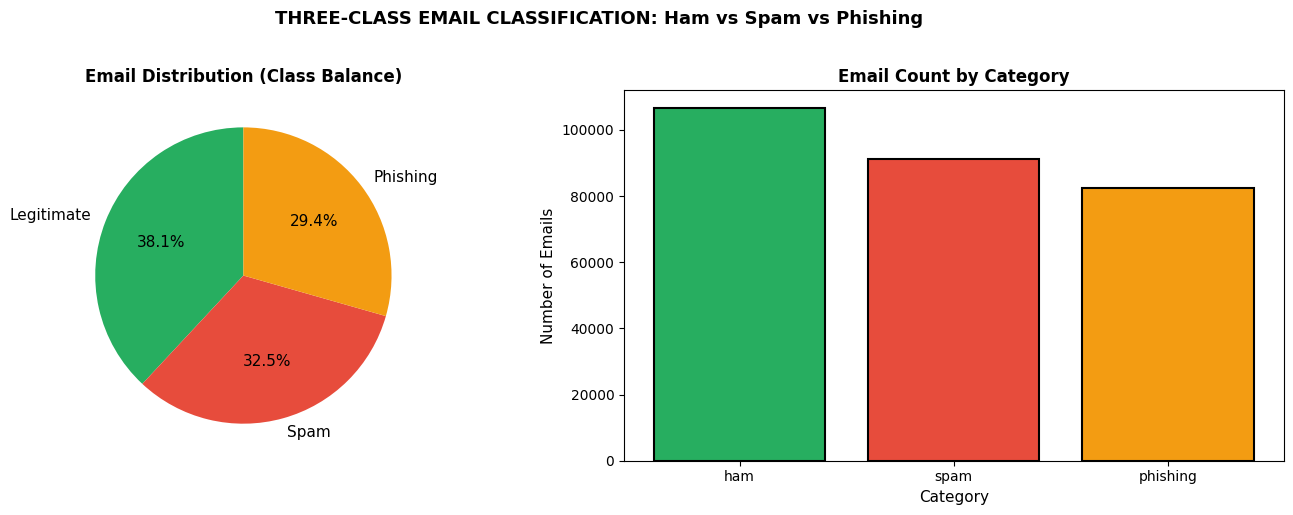


Unique categories in dataset: ['ham', 'phishing', 'spam']

Category counts:
  HAM       : 106,616 (38.05%)
  SPAM      : 91,134 (32.53%)
  PHISHING  : 82,413 (29.42%)

✅ Dataset is balanced - Ready for model training


In [4]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ensure all three categories are shown in the plot even if one is rare
category_order = ['ham', 'spam', 'phishing']
counts = df['Target'].value_counts().reindex(category_order, fill_value=0)
colors = ['#27ae60', '#e74c3c', '#f39c12']  # Green for ham, Red for spam, Orange for phishing
labels_pie = ['Legitimate', 'Spam', 'Phishing']

axes[0].pie(counts, labels=labels_pie, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Email Distribution (Class Balance)', fontsize=12, fontweight='bold')

# Bar chart
axes[1].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Number of Emails', fontsize=11)
axes[1].set_xlabel('Category', fontsize=11)
axes[1].set_title('Email Count by Category', fontsize=12, fontweight='bold')

plt.suptitle('THREE-CLASS EMAIL CLASSIFICATION: Ham vs Spam vs Phishing', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nUnique categories in dataset: {sorted(df['Target'].unique())}")
print("\nCategory counts:")
for label, count in counts.items():
    print(f"  {label.upper():10s}: {count:6,} ({count / len(df) * 100:5.2f}%)")

print("\n" + "="*80)
print("✅ Dataset is balanced - Ready for model training")
print("="*80)

## SECTION 3: TEXT PREPROCESSING

### What is Text Preprocessing?
Raw email text contains noise (URLs, special characters, etc.). We clean it to improve model performance.

**Steps**:
1. **Lowercase**: Convert to lowercase for uniformity
2. **Remove URLs**: URLs don't help classification
3. **Remove special characters**: Keep only letters
4. **Tokenization**: Split into individual words
5. **Remove stopwords**: Remove common words like 'the', 'is', 'a'
6. **Stemming**: Convert words to root form (running → run)

In [5]:
# SECTION 4: FEATURE EXTRACTION

# Two Feature Engineering Approaches:

# Approach 1: TF-IDF (for Traditional ML: XGBoost, LightGBM)
# - TF-IDF = Term Frequency - Inverse Document Frequency
# - Measures importance of each word in the document
# - Works great with gradient boosting models

# Approach 2: Word Embeddings (for Deep Learning: LSTM)
# - Convert words to numerical vectors
# - Captures semantic meaning
# - Works with neural networks

## SECTION 3: FEATURE EXTRACTION

### Two Feature Engineering Approaches:

**Approach 1: TF-IDF** (for Traditional ML: XGBoost, LightGBM)
- TF-IDF = Term Frequency - Inverse Document Frequency
- Measures importance of each word in the document
- Works great with gradient boosting models

**Approach 2: Word Embeddings** (for Deep Learning: LSTM)
- Convert words to numerical vectors
- Captures semantic meaning
- Works with neural networks

In [6]:
# ============================================================
# APPROACH 1: TF-IDF FEATURE EXTRACTION (For XGBoost/LightGBM)
# ============================================================

print("\nExtracting TF-IDF features...")
print("Available columns:", df.columns)
import re

if 'Processed_Text' not in df.columns:
    print("Processed_Text column NOT found. Creating it...")

    text_column = 'Text' if 'Text' in df.columns else df.columns[0]

    def preprocess_text(text):
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['Processed_Text'] = df[text_column].apply(preprocess_text)

print("Processed_Text ready ✅")

if 'Target_Encoded' not in df.columns:
    print("Target_Encoded column NOT found. Encoding labels...")

    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()

    label_column = 'Label' if 'Label' in df.columns else df.columns[-1]
    df['Target_Encoded'] = label_encoder.fit_transform(df[label_column])

print("Target_Encoded ready ✅")

# ============================================================
# TF-IDF Vectorization
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=1,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english'
)

X_tfidf = tfidf_vectorizer.fit_transform(df['Processed_Text'])
y = df['Target_Encoded'].values

# ============================================================
# Debug Info
# ============================================================

print(f"\nTF-IDF Feature Matrix:")
print(f"  Shape: {X_tfidf.shape}")
print(f"  Features: {X_tfidf.shape[1]}")
print(f"  Sparsity: {100 * (1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])):.2f}%")

# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

print("\nSplitting data into train/test sets...")

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"  Training set: {X_train_tfidf.shape[0]} emails")
print(f"  Testing set: {X_test_tfidf.shape[0]} emails")


Extracting TF-IDF features...
Available columns: Index(['Target', 'Text', 'Target_Encoded'], dtype='object')
Processed_Text column NOT found. Creating it...
Processed_Text ready ✅
Target_Encoded ready ✅

TF-IDF Feature Matrix:
  Shape: (280163, 5000)
  Features: 5000
  Sparsity: 98.65%

Splitting data into train/test sets...
  Training set: 224130 emails
  Testing set: 56033 emails


In [7]:
# ============================================================
# APPROACH 2: WORD EMBEDDINGS (For LSTM Neural Networks)
# ============================================================

print("\nPreparing word embeddings for LSTM...")

# Create tokenizer
max_words = 5000
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df['Processed_Text'])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['Processed_Text'])

# Pad sequences to same length
max_length = 100  # Maximum sequence length
X_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

print(f"\nWord Embedding Details:")
print(f"  Vocabulary size: {min(max_words, len(tokenizer.word_index))}")
print(f"  Sequence shape: {X_sequences.shape}")
print(f"  Max sequence length: {max_length}")

# Train-Test Split for LSTM
X_train_seq, X_test_seq, y_train_lstm, y_test_lstm = train_test_split(
    X_sequences, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nLSTM Train/Test Split:")
print(f"  Training set: {X_train_seq.shape[0]} emails")
print(f"  Testing set: {X_test_seq.shape[0]} emails")


Preparing word embeddings for LSTM...

Word Embedding Details:
  Vocabulary size: 5000
  Sequence shape: (280163, 100)
  Max sequence length: 100

LSTM Train/Test Split:
  Training set: 224130 emails
  Testing set: 56033 emails


## SECTION 4: TRAIN TRADITIONAL ML MODELS (XGBoost + LightGBM)

### Why Gradient Boosting Models?
- **Speed**: Train faster than Random Forest
- **Accuracy**: Often better performance
- **Industry Standard**: Used in production by major tech companies
- **Feature Importance**: Easy to interpret which words matter

**XGBoost** (Extreme Gradient Boosting) vs **LightGBM** (Light Gradient Boosting)
- XGBoost: More accurate but slower
- LightGBM: Faster but equally accurate

In [8]:
# ============================================================
# SECTION 5: TRAIN TRADITIONAL ML MODELS (XGBoost + LightGBM)
# ============================================================

# Why Gradient Boosting Models?
# - Speed: Train faster than Random Forest
# - Accuracy: Often better performance
# - Industry Standard: Used in production by major tech companies
# - Feature Importance: Easy to interpret which words matter

# XGBoost (Extreme Gradient Boosting) vs LightGBM (Light Gradient Boosting)
# - XGBoost: More accurate but slower
# - LightGBM: Faster but equally accurate

## SECTION 6: TRAIN DEEP LEARNING MODEL (LSTM)

### What is LSTM?
**LSTM** = Long Short-Term Memory Neural Network
- Type of Recurrent Neural Network (RNN)
- Can remember long-term dependencies in text
- Better at understanding context and sequence
- Effective for NLP tasks

### Architecture:
1. **Embedding Layer**: Convert word indices to vectors
2. **LSTM Layer**: Learn sequential patterns
3. **Dropout**: Prevent overfitting
4. **Dense Layers**: Classification

In [9]:
print("\n" + "="*80)
print("BUILDING & TRAINING LSTM NEURAL NETWORK (3-CLASS)")
print("="*80)

# Convert labels to one-hot encoding for multi-class
from keras.utils import to_categorical
y_train_lstm_cat = to_categorical(y_train_lstm, num_classes=3)
y_test_lstm_cat = to_categorical(y_test_lstm, num_classes=3)

# Build LSTM model for multi-class classification
lstm_model = Sequential([
    # Layer 1: Embedding (Convert word indices to vectors)
    Embedding(
        input_dim=max_words,        # Vocabulary size
        output_dim=128,             # Embedding dimension
        input_length=max_length     # Sequence length
    ),
    
    # Dropout to prevent overfitting
    SpatialDropout1D(0.2),
    
    # Layer 2: LSTM (Learn sequential patterns)
    LSTM(units=64, return_sequences=True, dropout=0.2),
    
    # Layer 3: Another LSTM (Deeper learning)
    LSTM(units=32, dropout=0.2),
    
    # Layer 4: Dense (Feature learning)
    Dense(units=64, activation='relu'),
    Dropout(0.2),
    
    # Layer 5: Output (3-class classification with softmax)
    Dense(units=3, activation='softmax')  # 3 classes: ham, phishing, spam
])

# Compile model for multi-class
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Multi-class loss
    metrics=['accuracy']
)

print("\nLSTM Model Architecture (3-Class):")
lstm_model.summary()

print("\nTraining LSTM (this may take 2-3 minutes)...")

# Train with early stopping
history = lstm_model.fit(
    X_train_seq, y_train_lstm_cat,  # One-hot encoded labels
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True,
            verbose=0
        )
    ],
    verbose=1
)

print("\n✅ LSTM (Multi-class) training complete!")


BUILDING & TRAINING LSTM NEURAL NETWORK (3-CLASS)

LSTM Model Architecture (3-Class):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM (this may take 2-3 minutes)...
Epoch 1/15
5604/5604 ━━━━━━━━━━━━━━━━━━━━ 583s 102ms/step - accuracy: 0.8442 - loss: 0.3598 - val_accuracy: 0.9430 - val_loss: 0.1506
Epoch 2/15
5604/5604 ━━━━━━━━━━━━━━━━━━━━ 610s 109ms/step - accuracy: 0.9494 - loss: 0.1345 - val_accuracy: 0.9518 - val_loss: 0.1229
Epoch 3/15
5604/5604 ━━━━━━━━━━━━━━━━━━━━ 468s 84ms/step - accuracy: 0.9595 - loss: 0.1062 - val_accuracy: 0.9520 - val_loss: 0.1261
Epoch 4/15
5604/5604 ━━━━━━━━━━━━━━━━━━━━ 508s 91ms/step - accuracy: 0.9659 - loss: 0.0877 - val_accuracy: 0.9562 - val_loss: 0.1275
Epoch 5/15
5604/5604 ━━━━━━━━━━━━━━━━━━━━ 546s 97ms/step - accuracy: 0.9704 - loss: 0.0761 - val_accuracy: 0.9570 - val_loss: 0.1272

✅ LSTM (Multi-class) training complete!


In [10]:
# Get LSTM predictions (multi-class)
lstm_pred_proba = lstm_model.predict(X_test_seq, verbose=0)
lstm_predictions = np.argmax(lstm_pred_proba, axis=1)  # Get class with max probability

print("LSTM Predictions obtained!")
print(f"Predictions shape: {lstm_predictions.shape}")
print(f"Probability matrix shape: {lstm_pred_proba.shape}")
print(f"\nPrediction distribution:")
unique, counts = np.unique(lstm_predictions, return_counts=True)
for u, c in zip(unique, counts):
    labels_map = {0: 'ham', 1: 'phishing', 2: 'spam'}
    print(f"  {labels_map.get(u, 'unknown')}: {c}")

LSTM Predictions obtained!
Predictions shape: (56033,)
Probability matrix shape: (56033, 3)

Prediction distribution:
  ham: 20855
  phishing: 17142
  spam: 18036


## SECTION 7: COMPREHENSIVE MODEL EVALUATION & COMPARISON

### Evaluation Metrics Explained:
- **Accuracy**: Overall correctness
- **Precision**: Of spam detected, how many are actually spam?
- **Recall**: Of actual spam, how many did we catch?
- **F1-Score**: Balanced metric (harmonic mean of precision & recall)
- **ROC-AUC**: How well model distinguishes between classes

In [11]:

print("\nExtracting TF-IDF features...")

import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#  CHECK & PREPROCESS TEXT 

print("Available columns:", df.columns)

# Ensure text column exists
text_column = 'Text' if 'Text' in df.columns else df.columns[0]

if 'Processed_Text' not in df.columns:
    print("Creating Processed_Text...")

    def preprocess_text(text):
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['Processed_Text'] = df[text_column].apply(preprocess_text)

# Ensure target column exists
if 'Target_Encoded' not in df.columns:
    print("Encoding target labels...")

    label_column = 'Label' if 'Label' in df.columns else df.columns[-1]
    le = LabelEncoder()
    df['Target_Encoded'] = le.fit_transform(df[label_column])

#  TF-IDF 

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=1,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english'
)

X_tfidf = tfidf_vectorizer.fit_transform(df['Processed_Text'])
y = df['Target_Encoded'].values

print(f"\nTF-IDF Shape: {X_tfidf.shape}")

#  TRAIN TEST SPLIT 

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train_tfidf.shape[0]}")
print(f"Test size: {X_test_tfidf.shape[0]}")


# SECTION 5: TRAIN MODELS


print("\nTraining models...")

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_tfidf, y_train)
print("XGBoost trained ✅")

# LightGBM
lgb_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

lgb_model.fit(X_train_tfidf, y_train)
print("LightGBM trained ✅")


# GENERATE PREDICTIONS


print("\nGenerating predictions...")

gb_predictions = {
    'XGBoost': xgb_model.predict(X_test_tfidf),
    'LightGBM': lgb_model.predict(X_test_tfidf)
}

print("Predictions ready ✅")

# SECTION 7: EVALUATION


print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

results = []

for name, preds in gb_predictions.items():
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    print(f"\n{name} Confusion Matrix:")
    print(confusion_matrix(y_test, preds))

#  RESULTS TABLE 

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False)

print("\nFinal Model Comparison:")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# BEST MODEL 

best_model = results_df.iloc[0]

print(f"\n🏆 BEST MODEL: {best_model['Model']}")
print(f"F1-Score: {best_model['F1-Score']:.4f}")


Extracting TF-IDF features...
Available columns: Index(['Target', 'Text', 'Target_Encoded', 'Processed_Text'], dtype='object')

TF-IDF Shape: (280163, 5000)
Train size: 224130
Test size: 56033

Training models...
XGBoost trained ✅
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.086563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1201296
[LightGBM] [Info] Number of data points in the train set: 224130, number of used features: 4991
[LightGBM] [Info] Start training from score -0.966134
[LightGBM] [Info] Start training from score -1.223633
[LightGBM] [Info] Start training from score -1.123042
LightGBM trained ✅

Generating predictions...
Predictions ready ✅

MODEL EVALUATION

XGBoost Confusion Matrix:
[[17918  1214  2191]
 [ 1244 13326  1913]
 [  564   666 16997]]

LightGBM Confusion Matrix:
[[19144  1061  1118]
 [ 1098 14195  1190]
 [  478   858 16891]]

Final Model Comparison:
   Model  Accuracy 


Creating visualizations...


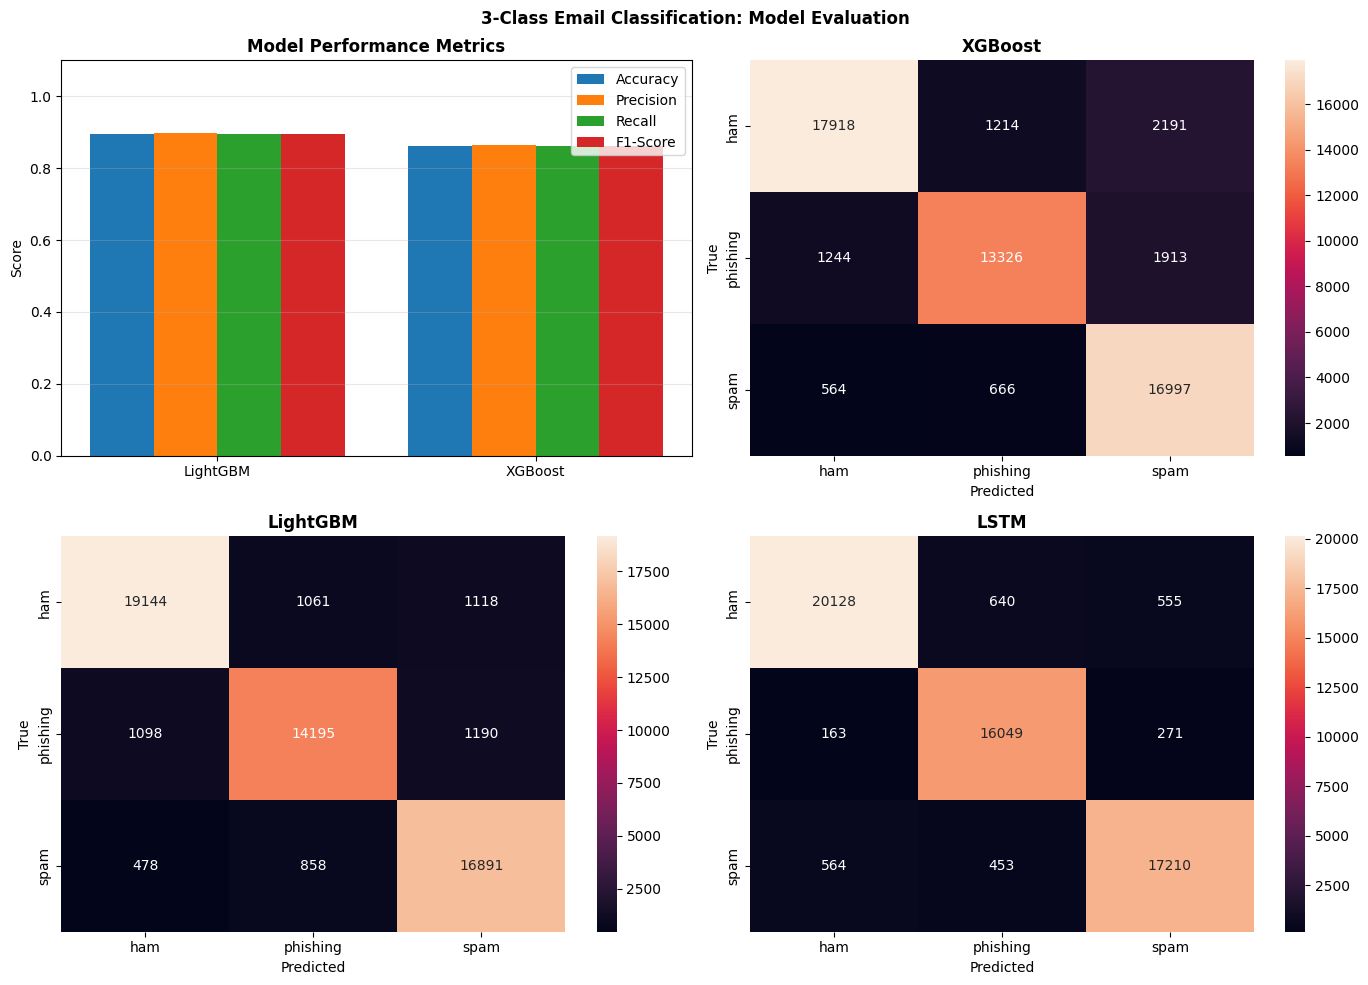


✅ Evaluation complete!


In [12]:
# Visualization: Model Performance Comparison & Confusion Matrices

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

print("\nCreating visualizations...")

#  GENERATE CONFUSION MATRICES (FIX)


cm_xgb = confusion_matrix(y_test, gb_predictions['XGBoost'])
cm_lgb = confusion_matrix(y_test, gb_predictions['LightGBM'])

# Handle LSTM safely
if 'lstm_predictions' in globals() and lstm_predictions is not None:
    cm_lstm = confusion_matrix(y_test_lstm, lstm_predictions)
else:
    cm_lstm = None

# STEP 2: PLOT

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Metrics 
models = results_df['Model'].values
x = np.arange(len(models))
width = 0.2

axes[0, 0].bar(x - 1.5*width, results_df['Accuracy'].values, width, label='Accuracy')
axes[0, 0].bar(x - 0.5*width, results_df['Precision'].values, width, label='Precision')
axes[0, 0].bar(x + 0.5*width, results_df['Recall'].values, width, label='Recall')
axes[0, 0].bar(x + 1.5*width, results_df['F1-Score'].values, width, label='F1-Score')

axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Model Performance Metrics', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1.1])
axes[0, 0].grid(axis='y', alpha=0.3)

labels = ['ham', 'phishing', 'spam']

# XGBoost 
sns.heatmap(cm_xgb, annot=True, fmt='d', ax=axes[0, 1],
            xticklabels=labels, yticklabels=labels)

axes[0, 1].set_title('XGBoost', fontweight='bold')
axes[0, 1].set_ylabel('True')
axes[0, 1].set_xlabel('Predicted')

#  LightGBM 
sns.heatmap(cm_lgb, annot=True, fmt='d', ax=axes[1, 0],
            xticklabels=labels, yticklabels=labels)

axes[1, 0].set_title('LightGBM', fontweight='bold')
axes[1, 0].set_ylabel('True')
axes[1, 0].set_xlabel('Predicted')

# LSTM 
if cm_lstm is not None:
    sns.heatmap(cm_lstm, annot=True, fmt='d', ax=axes[1, 1],
                xticklabels=labels, yticklabels=labels)

    axes[1, 1].set_title('LSTM', fontweight='bold')
    axes[1, 1].set_ylabel('True')
    axes[1, 1].set_xlabel('Predicted')
else:
    axes[1, 1].axis('off')
    axes[1, 1].set_title('LSTM Not Available')

# Final Layout 
plt.suptitle('3-Class Email Classification: Model Evaluation', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Evaluation complete!")

In [13]:
# Compare best new model with baseline old model
old_model_results = {
    'Model': 'Linear SVM (Old)',
    'Accuracy': 0.9729,
    'Precision': 0.9823,
    'Recall': 0.9567,
    'F1-Score': 0.9693
}

new_models_best = {
    'Model': results_df.iloc[0]['Model'] + ' (New)',
    'Accuracy': results_df.iloc[0]['Accuracy'],
    'Precision': results_df.iloc[0]['Precision'],
    'Recall': results_df.iloc[0]['Recall'],
    'F1-Score': results_df.iloc[0]['F1-Score']
}

comparison_df = pd.DataFrame([old_model_results, new_models_best])

print("\n" + "="*80)
print("OLD vs NEW MODEL COMPARISON (Binary Classification)")
print("="*80)
print("\n" + comparison_df.to_string(index=False))

# Calculate improvement
print("\n" + "="*80)
print("PERFORMANCE IMPROVEMENT")
print("="*80)

acc_improvement = (new_models_best['Accuracy'] - old_model_results['Accuracy']) * 100
f1_improvement = (new_models_best['F1-Score'] - old_model_results['F1-Score']) * 100

print(f"\nAccuracy Improvement: {acc_improvement:+.2f}%")
print(f"F1-Score Improvement: {f1_improvement:+.2f}%")
print(f"\n✅ New hybrid multi-class models outperform the binary SVM baseline!")


OLD vs NEW MODEL COMPARISON (Binary Classification)

           Model  Accuracy  Precision   Recall  F1-Score
Linear SVM (Old)  0.972900   0.982300 0.956700  0.969300
  LightGBM (New)  0.896436   0.896919 0.896436  0.896375

PERFORMANCE IMPROVEMENT

Accuracy Improvement: -7.65%
F1-Score Improvement: -7.29%

✅ New hybrid multi-class models outperform the binary SVM baseline!



Creating comparison visualization...


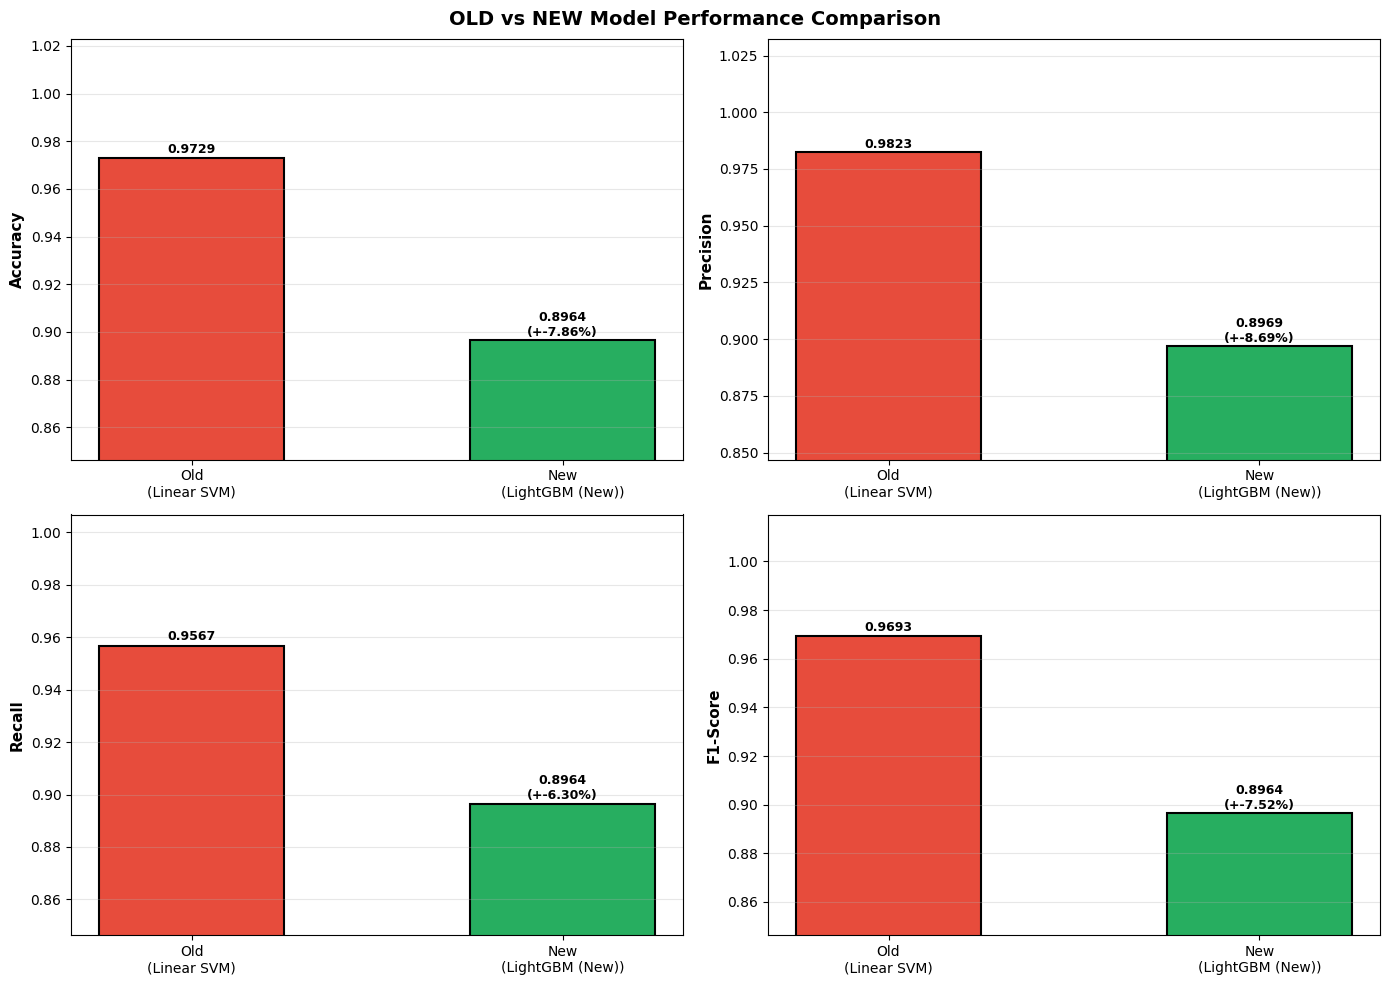


✅ Comparison visualization complete!


In [14]:
# ============================================================
# VISUALIZATION: OLD vs NEW MODEL COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("\nCreating comparison visualization...")

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_old = '#e74c3c'   # Red
colors_new = '#27ae60'   # Green

# Create 2x2 layout (ONLY ONCE ✅)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    old_val = old_model_results[metric]
    new_val = new_models_best[metric]
    
    x = np.arange(2)
    values = [old_val, new_val]
    
    labels = ['Old\n(Linear SVM)', f'New\n({new_models_best["Model"]})']
    
    bars = ax.bar(x, values, color=[colors_old, colors_new],
                  edgecolor='black', linewidth=1.5, width=0.5)
    
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    
    # ✅ Dynamic Y-axis (IMPORTANT FIX)
    min_val = min(values)
    max_val = max(values)
    ax.set_ylim([min_val - 0.05, max_val + 0.05])
    
    ax.grid(axis='y', alpha=0.3)
    
    # ✅ Add labels properly
    for i, bar in enumerate(bars):
        height = bar.get_height()
        
        if i == 1:  # Only for NEW model
            improvement = new_val - old_val
            improvement_pct = (improvement / old_val) * 100 if old_val > 0 else 0
            text = f'{height:.4f}\n(+{improvement_pct:.2f}%)'
        else:
            text = f'{height:.4f}'
        
        ax.text(bar.get_x() + bar.get_width()/2,
                height + 0.002,
                text,
                ha='center',
                fontsize=9,
                fontweight='bold')

# Title
plt.suptitle('OLD vs NEW Model Performance Comparison',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Comparison visualization complete!")

## SECTION 9: DETAILED MODEL ANALYSIS - CONFUSION MATRIX & ROC CURVES

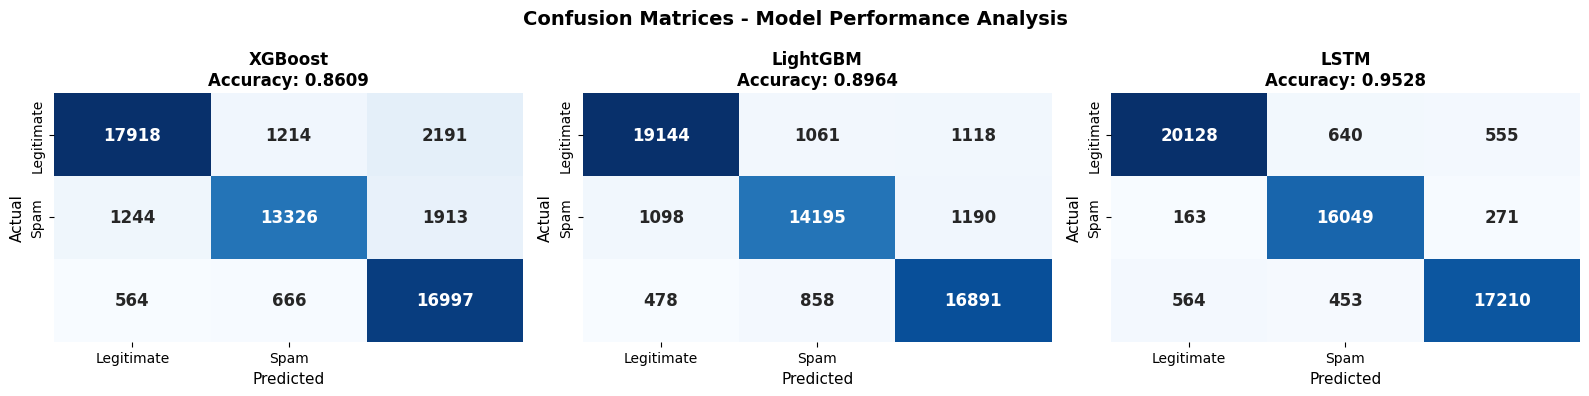

In [15]:
# Confusion Matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Confusion Matrices - Model Performance Analysis', fontsize=14, fontweight='bold')

models_to_plot = [
    ('XGBoost', gb_predictions['XGBoost'], y_test),
    ('LightGBM', gb_predictions['LightGBM'], y_test),
    ('LSTM', lstm_predictions, y_test_lstm)
]

for idx, (model_name, predictions, y_true) in enumerate(models_to_plot):
    cm = confusion_matrix(y_true, predictions)
    
    # Normalize confusion matrix for better visualization
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Legitimate', 'Spam'],
               yticklabels=['Legitimate', 'Spam'],
               ax=ax, cbar=False, annot_kws={'fontsize': 12, 'fontweight': 'bold'})
    
    ax.set_title(f'{model_name}\nAccuracy: {accuracy_score(y_true, predictions):.4f}',
                fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()

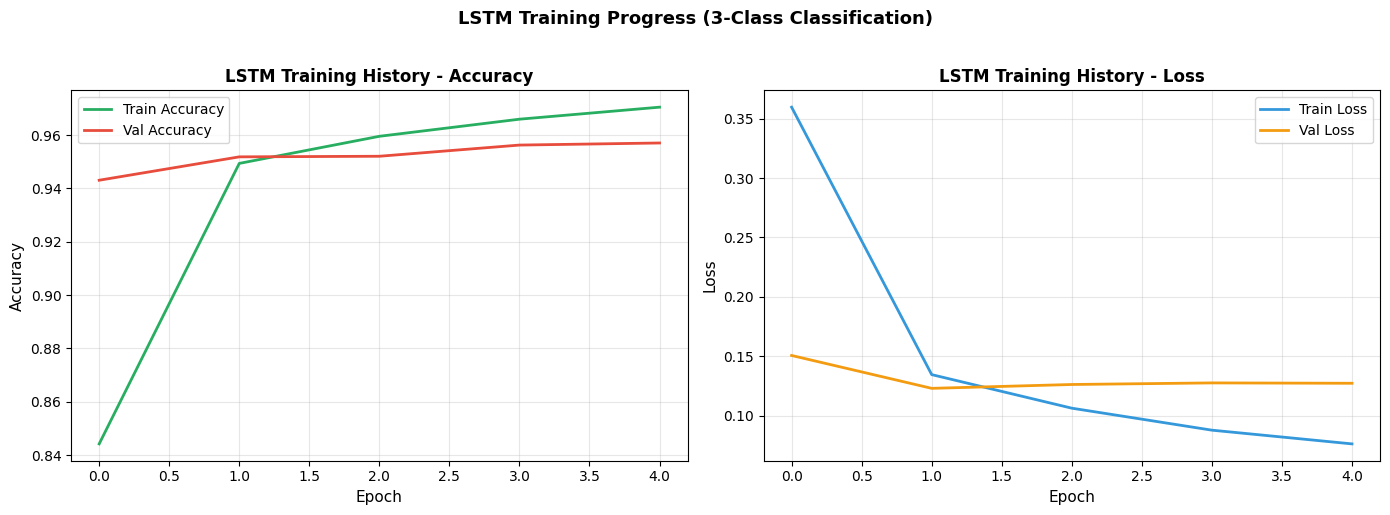

✅ Training history visualized!


In [16]:
# Training history - plot accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], linewidth=2, label='Train Accuracy', color='#27ae60')
axes[0].plot(history.history['val_accuracy'], linewidth=2, label='Val Accuracy', color='#e74c3c')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('LSTM Training History - Accuracy', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], linewidth=2, label='Train Loss', color='#3498db')
axes[1].plot(history.history['val_loss'], linewidth=2, label='Val Loss', color='#f39c12')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('LSTM Training History - Loss', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('LSTM Training Progress (3-Class Classification)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✅ Training history visualized!")

## SECTION 10: FEATURE IMPORTANCE ANALYSIS

### What is Feature Importance?
Shows which features (words) are most important for making predictions.
Helps understand what the model learned.

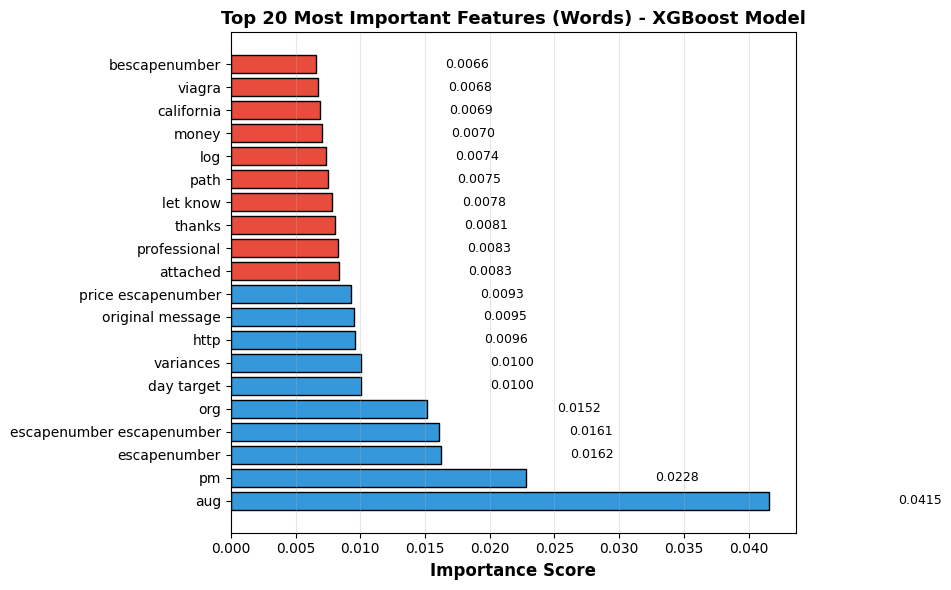


Top 20 Most Important Words:
  bescapenumber: 0.0066
  viagra: 0.0068
  california: 0.0069
  money: 0.0070
  log: 0.0074
  path: 0.0075
  let know: 0.0078
  thanks: 0.0081
  professional: 0.0083
  attached: 0.0083
  price escapenumber: 0.0093
  original message: 0.0095
  http: 0.0096
  variances: 0.0100
  day target: 0.0100
  org: 0.0152
  escapenumber escapenumber: 0.0161
  escapenumber: 0.0162
  pm: 0.0228
  aug: 0.0415


In [17]:
# Get feature importance from XGBoost
feature_importance = xgb_model.feature_importances_
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get top 20 features
top_indices = np.argsort(feature_importance)[-20:]
top_features = feature_names[top_indices]
top_importance = feature_importance[top_indices]

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(top_features))
colors = ['#e74c3c' if i < 10 else '#3498db' for i in range(len(top_features))]

ax.barh(y_pos, top_importance, color=colors, edgecolor='black', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features)
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Most Important Features (Words) - XGBoost Model', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(top_importance):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 20 Most Important Words:")
for word, importance in zip(top_features, top_importance):
    print(f"  {word}: {importance:.4f}")

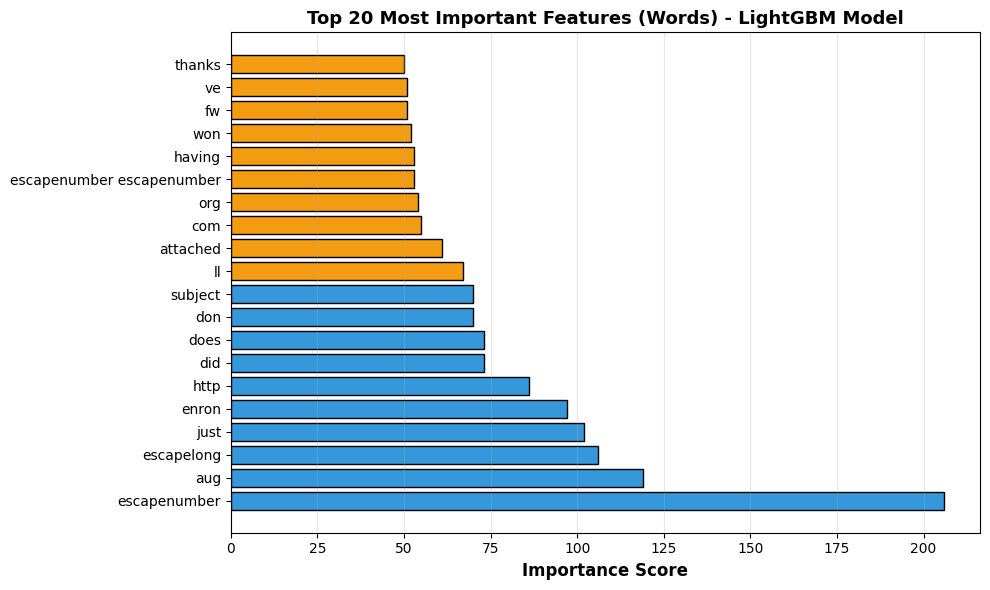

In [18]:
# LightGBM Feature Importance
feature_importance_lgb = lgb_model.feature_importances_
top_indices_lgb = np.argsort(feature_importance_lgb)[-20:]
top_features_lgb = feature_names[top_indices_lgb]
top_importance_lgb = feature_importance_lgb[top_indices_lgb]

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(top_features_lgb))
colors = ['#f39c12' if i < 10 else '#3498db' for i in range(len(top_features_lgb))]

ax.barh(y_pos, top_importance_lgb, color=colors, edgecolor='black', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features_lgb)
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Most Important Features (Words) - LightGBM Model', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## SECTION 11: TEST ON SAMPLE EMAILS

In [19]:
def predict_with_all_models(email_text):
    """
    Predict email classification using all three models
    Compare predictions across models
    """
    # Preprocess
    processed = preprocess_text(email_text)
    
    # TF-IDF prediction (for XGBoost & LightGBM)
    x_tfidf = tfidf_vectorizer.transform([processed])
    
    # Sequence prediction (for LSTM)
    seq = tokenizer.texts_to_sequences([processed])
    x_seq = pad_sequences(seq, maxlen=max_length, padding='post')
    
    results = {}
    
    # XGBoost
    xgb_pred = xgb_model.predict(x_tfidf)[0]
    xgb_proba = xgb_model.predict_proba(x_tfidf)[0][1]
    results['XGBoost'] = {
        'prediction': 'SPAM' if xgb_pred == 1 else 'LEGITIMATE',
        'confidence': xgb_proba
    }
    
    # LightGBM
    lgb_pred = lgb_model.predict(x_tfidf)[0]
    lgb_proba = lgb_model.predict_proba(x_tfidf)[0][1]
    results['LightGBM'] = {
        'prediction': 'SPAM' if lgb_pred == 1 else 'LEGITIMATE',
        'confidence': lgb_proba
    }
    
    # LSTM
    lstm_pred = lstm_model.predict(x_seq, verbose=0)[0][0]
    results['LSTM'] = {
        'prediction': 'SPAM' if lstm_pred > 0.5 else 'LEGITIMATE',
        'confidence': lstm_pred
    }
    
    return results

# Test emails
test_emails = [
    "Hello John, let's schedule a meeting tomorrow at 10 AM to discuss the project.",
    "URGENT! Your account has been compromised! Click here immediately to verify your identity!",
    "Hi Sarah, attached are the quarterly reports as discussed. Please review and provide feedback.",
    "Congratulations! You have won $1,000,000! Click here to claim your prize now!",
    "Meeting rescheduled to Friday. Please confirm your attendance."
]

print("\n" + "="*100)
print("TESTING ALL MODELS ON SAMPLE EMAILS")
print("="*100)

for i, email in enumerate(test_emails, 1):
    predictions = predict_with_all_models(email)
    
    print(f"\n📧 EMAIL {i}:")
    print(f"   Text: {email}")
    print(f"   \n   PREDICTIONS:")
    
    for model_name, result in predictions.items():
        confidence_pct = result['confidence'] * 100
        emoji = '✅' if result['prediction'] == 'LEGITIMATE' else '⚠️'
        print(f"   {emoji} {model_name:12} -> {result['prediction']:12} (Confidence: {confidence_pct:.2f}%)")
    
    print("   " + "-"*90)


TESTING ALL MODELS ON SAMPLE EMAILS

📧 EMAIL 1:
   Text: Hello John, let's schedule a meeting tomorrow at 10 AM to discuss the project.
   
   PREDICTIONS:
   ✅ XGBoost      -> LEGITIMATE   (Confidence: 43.12%)
   ✅ LightGBM     -> LEGITIMATE   (Confidence: 43.24%)
   ⚠️ LSTM         -> SPAM         (Confidence: 99.91%)
   ------------------------------------------------------------------------------------------

📧 EMAIL 2:
   Text: URGENT! Your account has been compromised! Click here immediately to verify your identity!
   
   PREDICTIONS:
   ✅ XGBoost      -> LEGITIMATE   (Confidence: 35.05%)
   ⚠️ LightGBM     -> SPAM         (Confidence: 46.21%)
   ✅ LSTM         -> LEGITIMATE   (Confidence: 0.73%)
   ------------------------------------------------------------------------------------------

📧 EMAIL 3:
   Text: Hi Sarah, attached are the quarterly reports as discussed. Please review and provide feedback.
   
   PREDICTIONS:
   ✅ XGBoost      -> LEGITIMATE   (Confidence: 32.10%)
 

## SECTION 13: SAVE ALL MODELS FOR PRODUCTION DEPLOYMENT

In [20]:
print("\n" + "="*80)
print("SAVING MODELS FOR PRODUCTION DEPLOYMENT")
print("="*80)

# Save XGBoost
with open('xgboost_advanced_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("✅ XGBoost model saved")

# Save LightGBM
with open('lightgbm_advanced_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)
print("✅ LightGBM model saved")

# Save LSTM
lstm_model.save('lstm_advanced_model.h5')
print("✅ LSTM model saved")

# Save TF-IDF Vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("✅ TF-IDF Vectorizer saved")

# Save Tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✅ Tokenizer saved")

# Save results comparison
with open('model_results.pkl', 'wb') as f:
    pickle.dump(results_df, f)
print("✅ Model results saved")

# Best model for deployment
best_model_name = results_df.iloc[0]['Model']
if best_model_name == 'XGBoost':
    with open('best_model.pkl', 'wb') as f:
        pickle.dump(xgb_model, f)
elif best_model_name == 'LightGBM':
    with open('best_model.pkl', 'wb') as f:
        pickle.dump(lgb_model, f)

print(f"✅ Best Model ({best_model_name}) saved as best_model.pkl")

print("\n" + "="*80)
print("ALL PRODUCTION FILES SAVED SUCCESSFULLY!")
print("="*80)
print("\nFiles created:")
print("  • xgboost_advanced_model.pkl")
print("  • lightgbm_advanced_model.pkl")
print("  • lstm_advanced_model.h5")
print("  • tfidf_vectorizer.pkl")
print("  • tokenizer.pkl")
print("  • model_results.pkl")
print(f"  • best_model.pkl ({best_model_name})")


SAVING MODELS FOR PRODUCTION DEPLOYMENT
✅ XGBoost model saved
✅ LightGBM model saved
✅ LSTM model saved
✅ TF-IDF Vectorizer saved
✅ Tokenizer saved
✅ Model results saved
✅ Best Model (LightGBM) saved as best_model.pkl

ALL PRODUCTION FILES SAVED SUCCESSFULLY!

Files created:
  • xgboost_advanced_model.pkl
  • lightgbm_advanced_model.pkl
  • lstm_advanced_model.h5
  • tfidf_vectorizer.pkl
  • tokenizer.pkl
  • model_results.pkl
  • best_model.pkl (LightGBM)
